## Overview

This project builds a machine learning model to detect fraudulent credit card transactions using highly imbalanced data. The focus is on practical evaluation (precision/recall trade-offs) and translating model decisions into real business impact.

# Credit Card Fraud Detection

**Dataset:** ULB Credit Card Fraud (Kaggle) — 284,807 transactions from September 2013

## Business Context

Fraud detection is a classic example of an **imbalanced classification** problem. In this dataset, only about 0.172% of transactions are fraudulent, meaning a model that simply predicts "not fraud" for every transaction would achieve 99.83% accuracy, but it would completely fail to detect any actual fraud.

Because of this, **accuracy is not a useful metric**. Instead, we focus on:

- **AUPRC (Area Under the Precision-Recall Curve):** Evaluates performance on the minority (fraud) class. A random model scores around 0.0017, so higher values indicate better performance.
- **F1 Score:** The harmonic mean of precision and recall, balancing the trade-off between missing fraud (false negatives) and incorrectly flagging legitimate transactions (false positives).
- **Confusion Matrix:** Provides a breakdown of true positives, false positives, true negatives, and false negatives.

## Dataset Features

- `V1`–`V28`: PCA-transformed features (original variables are confidential)
- `Time`: Seconds since the first transaction in the dataset
- `Amount`: Transaction amount in euros
- `Class`: Target variable (`1` = fraud, `0` = legitimate)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, model, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('creditcard.csv')

print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['class'].value_counts())
print(f'\nFraud rate: {df["class"].mean() * 100:.4f}%')

df.head()

Shape: (284807, 31)

Class distribution:
class
False    284315
True        492
Name: count, dtype: int64

Fraud rate: 0.1727%


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,False
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,False
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,False
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,False
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,False


In [3]:
# Check for missing values and data types
print('Missing values per column:')
print(df.isnull().sum().sum(), 'total missing values')

print('\nData types:')
print(df.dtypes.value_counts())

print('\nDescriptive statistics for Amount and Time:')
df[['time', 'amount']].describe().round(2)

Missing values per column:
0 total missing values

Data types:
float64    29
int64       1
bool        1
Name: count, dtype: int64

Descriptive statistics for Amount and Time:


,time,amount
count,284807.00,284807.00
mean,94813.86,88.35
std,47488.15,250.12
min,0.00,0.00
25%,54201.50,5.60
50%,84692.00,22.00
75%,139320.50,77.16
max,172792.00,25691.16


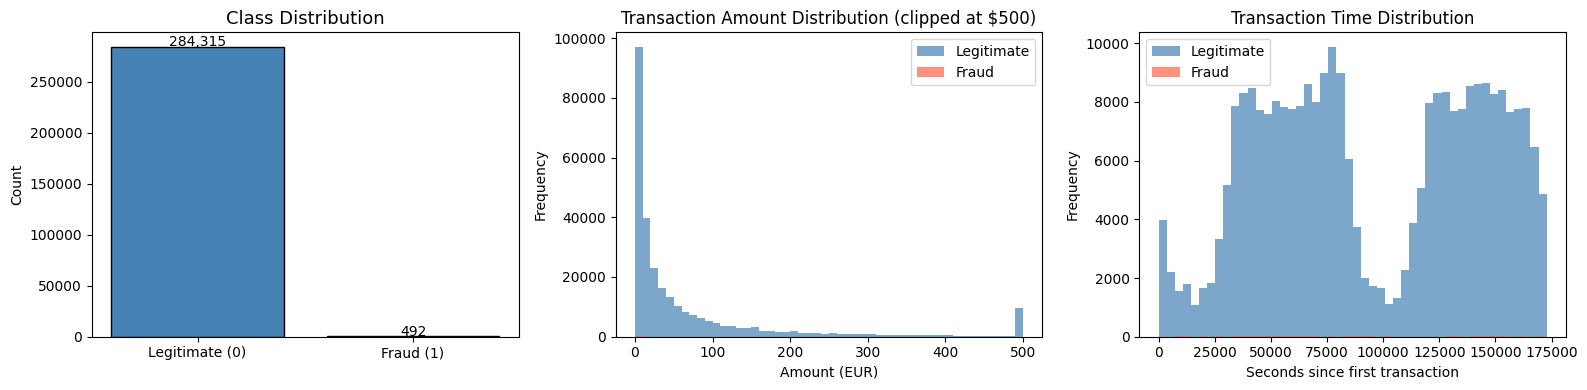

Saved: eda_overview.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Class imbalance bar chart ---
class_counts = df['class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# --- Transaction Amount by class ---
df[df['class'] == 0]['amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.7, color='steelblue', label='Legitimate')
df[df['class'] == 1]['amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.7, color='tomato', label='Fraud')
axes[1].set_title('Transaction Amount Distribution (clipped at $500)', fontsize=12)
axes[1].set_xlabel('Amount (EUR)')
axes[1].legend()

# --- Transaction Time by class ---
df[df['class'] == 0]['time'].plot(
    kind='hist', bins=48, ax=axes[2], alpha=0.7, color='steelblue', label='Legitimate')
df[df['class'] == 1]['time'].plot(
    kind='hist', bins=48, ax=axes[2], alpha=0.7, color='tomato', label='Fraud')
axes[2].set_title('Transaction Time Distribution', fontsize=12)
axes[2].set_xlabel('Seconds since first transaction')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

### Key Observations

- **Severe class imbalance:** 284,315 legitimate vs. 492 fraud (~0.17%). Accuracy is misleading, so we focus on precision, recall, and AUPRC.

- **Transaction amounts:** Strongly right-skewed, with most transactions at low values. TStrongly right-skewed, with most transactions at low values. Fraud overlaps with legitimate transactions, but the concentration of small transactions is consistent with the intuition that fraudsters may test cards using small charges before larger ones.

- **Transaction timing:** Clear cyclical pattern (likely daily behavior). Fraud occurs throughout, not concentrated in a specific time window.

### Modeling Implications

- Handle imbalance with resampling or class weighting  
- Rely on feature interactions rather than single variables  
- Prioritize recall while controlling false positives

---
## 2. Preprocessing

Two features need attention before modeling:
- **`Amount`**: raw euro amounts range from 0 to ~25,000. We standardize to zero mean / unit variance so the model isn't dominated by scale.
- **`Time`**: seconds elapsed — we standardize it for the same reason.

The `V1`–`V28` features are already PCA-transformed (zero-centered, unit variance) by the data provider, so they don't need further scaling.

In [5]:
# Scale Amount and Time; V1-V28 are already standardized
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['amount']])
df['Time_scaled']   = scaler.fit_transform(df[['time']])

# Drop the original raw columns
df_model = df.drop(columns=['amount', 'time'])

# Separate features and target
X = df_model.drop(columns=['class'])
y = df_model['class']

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature columns: {list(X.columns)}')

Feature matrix shape: (284807, 30)
Target shape: (284807,)
Feature columns: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'Amount_scaled', 'Time_scaled']


In [6]:
# Stratified split — preserves the fraud rate in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # critical for imbalanced data
)

print(f'Train size: {X_train.shape[0]:,} ({y_train.sum()} fraud, {(y_train==0).sum()} legitimate)')
print(f'Test size:  {X_test.shape[0]:,} ({y_test.sum()} fraud, {(y_test==0).sum()} legitimate)')

Train size: 227,845 (394 fraud, 227451 legitimate)
Test size:  56,962 (98 fraud, 56864 legitimate)


---
## 3. Handling Class Imbalance with Sample Weights

**Why not just use the raw imbalanced data?**  
Tree-based models can be biased toward the majority class because they optimize overall loss. Without correction, the model learns that "always predict legitimate" is a cheap strategy.

**`sample_weight` — the GradientBoostingClassifier approach:**  
`GradientBoostingClassifier` doesn't expose `class_weight` (unlike `RandomForestClassifier` or `LogisticRegression`). The equivalent is passing per-sample weights directly to `fit()`. `compute_sample_weight('balanced')` calculates these as:

```
weight = n_samples / (n_classes × class_count)
```

Fraud samples receive a weight ~578x higher than legitimate ones, so misclassifying a fraud transaction costs the model ~578x more in loss. No data generation or resampling needed — the training set stays at 228k rows.

Note: the **test set is never reweighted** — it must reflect the true real-world distribution so evaluation metrics are meaningful.

In [7]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

fraud_w = sample_weights[y_train == True].mean()
legit_w = sample_weights[y_train == False].mean()

print(f'Training samples:    {len(X_train):,} (no resampling)')
print(f'  Legitimate weight: {legit_w:.4f}')
print(f'  Fraud weight:      {fraud_w:.2f}')
print(f'  Fraud/legit ratio: {fraud_w / legit_w:.0f}x')

Training samples:    227,845 (no resampling)
  Legitimate weight: 0.5009
  Fraud weight:      289.14
  Fraud/legit ratio: 577x


---
## 4. Model: Gradient Boosting (Fixed Configuration)

**Why Gradient Boosting?**  
Gradient Boosting builds an ensemble of shallow decision trees sequentially, where each tree corrects the residual errors of the previous one. It is well-suited for tabular fraud data because it captures non-linear feature interactions, is robust to scale differences, and outputs probability scores useful for threshold tuning.

**Why no grid search here?**  
For a portfolio baseline, a well-chosen fixed configuration is more practical than an exhaustive search. The parameters below are a standard starting point for fraud detection on tabular data:

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | `50` | Enough rounds for signal; keeps runtime under 2 minutes |
| `max_depth` | `3` | Shallow trees — controls overfitting, typical for boosting |
| `learning_rate` | `0.1` | Standard shrinkage; lower values need more estimators to compensate |
| `subsample` | `1.0` | Full data per round — stochastic boosting adds value with more estimators |

In production, you'd tune these (and `min_samples_leaf`, `max_features`) with a proper search — see the Next Steps section.

In [8]:
best_model = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    random_state=RANDOM_STATE,
)

print('Fitting model...')
best_model.fit(X_train, y_train, sample_weight=sample_weights)
print('Done.')

Fitting model...
Done.


In [9]:
# Confirm the model configuration that was fit
params = best_model.get_params()
display_params = ['n_estimators', 'max_depth', 'learning_rate', 'subsample']
for p in display_params:
    print(f'  {p}: {params[p]}')

  n_estimators: 50
  max_depth: 3
  learning_rate: 0.1
  subsample: 1.0


---
## 5. Model Evaluation

We evaluate the best model on the **held-out test set**, which was never touched during training, as it preserves the real-world fraud rate of ~0.172%.

### Why AUPRC over AUROC?
Both AUROC and AUPRC are threshold-independent metrics, but for severely imbalanced datasets:
- **AUROC** can be misleadingly high because true negatives vastly outnumber false positives
- **AUPRC** focuses only on the fraud class — it is far more informative when fraud is rare

A random classifier achieves AUPRC ≈ 0.0017 on this dataset; anything well above that indicates genuine fraud signal.

In [10]:
# Predict class labels and fraud probability scores
y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # P(fraud)

# --- Core metrics ---
auprc = average_precision_score(y_test, y_pred_proba)
f1    = f1_score(y_test, y_pred)

print('=' * 45)
print(f'  AUPRC (Average Precision):  {auprc:.4f}')
print(f'  F1 Score (fraud class):     {f1:.4f}')
print('=' * 45)
print('\nFull classification report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

  AUPRC (Average Precision):  0.6961
  F1 Score (fraud class):     0.1800

Full classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.10      0.91      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962



True Positives  (fraud caught):       89  (90.8% of all fraud)
False Negatives (fraud missed):       9  (9.2% of all fraud)
False Positives (legit flagged):      802  (1.41% of all legit)
True Negatives  (legit cleared):      56062


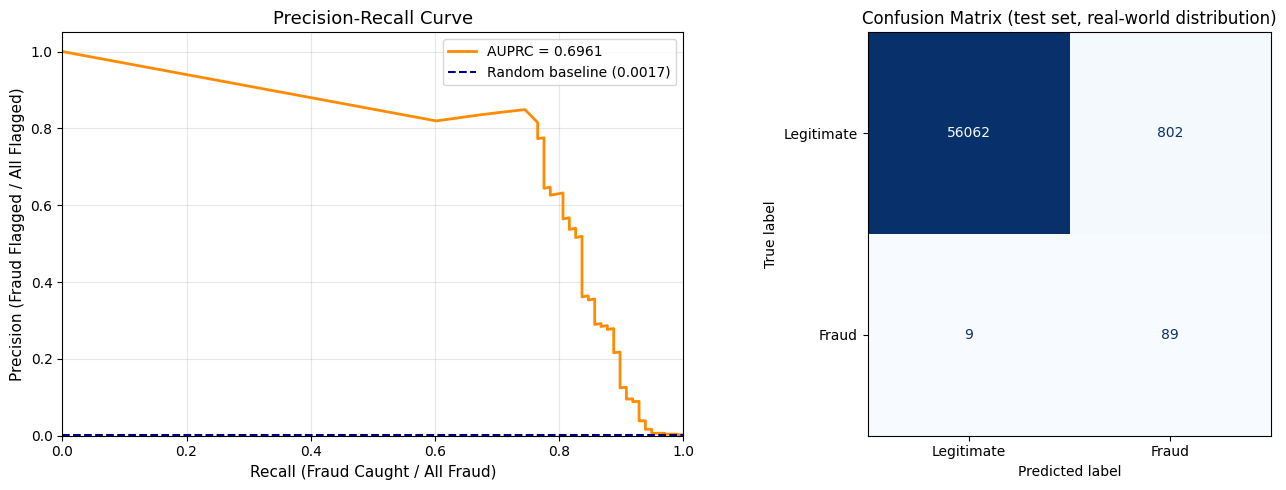

Saved: evaluation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
axes[0].plot(recall, precision, color='darkorange', lw=2,
             label=f'AUPRC = {auprc:.4f}')
axes[0].axhline(y=df['class'].mean(), color='navy', linestyle='--', lw=1.5,
                label=f'Random baseline ({df["class"].mean():.4f})')
axes[0].set_xlabel('Recall (Fraud Caught / All Fraud)', fontsize=11)
axes[0].set_ylabel('Precision (Fraud Flagged / All Flagged)', fontsize=11)
axes[0].set_title('Precision-Recall Curve', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].grid(alpha=0.3)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (test set, real-world distribution)', fontsize=12)

# Annotate with percentages
total_fraud = y_test.sum()
total_legit = (y_test == False).sum()
tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (fraud caught):       {tp}  ({tp/total_fraud*100:.1f}% of all fraud)')
print(f'False Negatives (fraud missed):       {fn}  ({fn/total_fraud*100:.1f}% of all fraud)')
print(f'False Positives (legit flagged):      {fp}  ({fp/total_legit*100:.2f}% of all legit)')
print(f'True Negatives  (legit cleared):      {tn}')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation.png')

**Reading the confusion matrix in business terms:**
- **True Positives**: fraud cases the model correctly blocked — direct financial loss prevented
- **False Negatives**: missed fraud — financial loss to the bank/cardholder
- **False Positives**: legitimate transactions declined — customer friction and potential churn
- **True Negatives**: the vast majority — correctly cleared legitimate transactions

In practice, the business sets a **threshold on P(fraud)** to trade off recall vs precision based on the cost of each error type.

---
## 6. Threshold Analysis

The default threshold of 0.5 is rarely optimal for imbalanced problems. By sweeping thresholds we can visualize the precision-recall tradeoff and pick an operating point that matches our business cost structure.

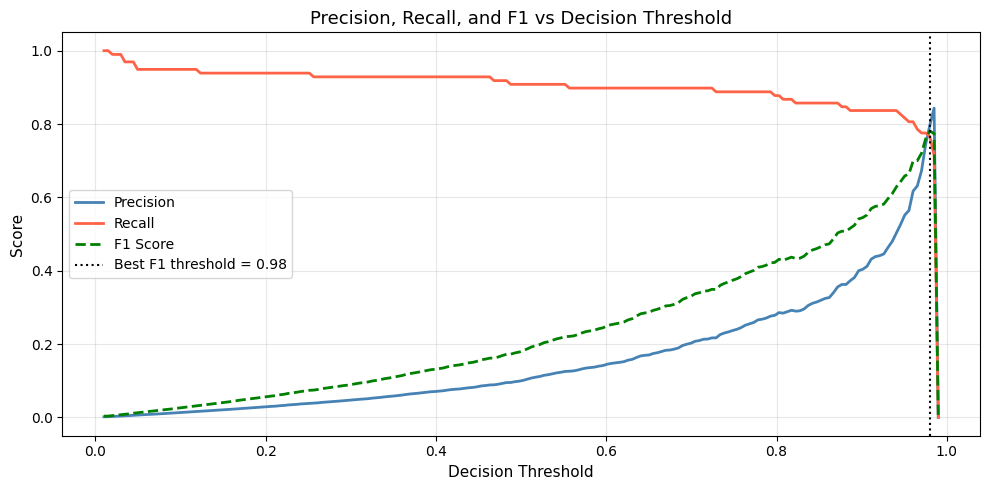

Threshold that maximizes F1: 0.980
F1 at that threshold:        0.7813
Precision at that threshold: 0.7979
Recall at that threshold:    0.7653


In [13]:
from sklearn.metrics import precision_score, recall_score

# Compute precision, recall, and F1 at each threshold
thresholds_range = np.linspace(0.01, 0.99, 200)
f1_scores, precisions, recalls = [], [], []

for t in thresholds_range:
    y_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_t, zero_division=0))
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t, zero_division=0))

best_t_idx = np.argmax(f1_scores)
best_threshold = thresholds_range[best_t_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, precisions, label='Precision', color='steelblue', lw=2)
ax.plot(thresholds_range, recalls,    label='Recall',    color='tomato',    lw=2)
ax.plot(thresholds_range, f1_scores,  label='F1 Score',  color='green',     lw=2, linestyle='--')
ax.axvline(best_threshold, color='black', linestyle=':', lw=1.5,
           label=f'Best F1 threshold = {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision, Recall, and F1 vs Decision Threshold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold that maximizes F1: {best_threshold:.3f}')
print(f'F1 at that threshold:        {f1_scores[best_t_idx]:.4f}')
print(f'Precision at that threshold: {precisions[best_t_idx]:.4f}')
print(f'Recall at that threshold:    {recalls[best_t_idx]:.4f}')

### Threshold Selection Insight

There’s a clear trade-off between precision and recall as we adjust the decision threshold. At lower thresholds, the model catches more fraud (high recall), but also flags more legitimate transactions (low precision). As we increase the threshold, it becomes more conservative (precision increases), but we start missing more fraud.

The best F1 score occurs at a **high threshold (~0.98)**, where precision (roughly 0.80) and recall (roughly 0.77) are fairly balanced. This suggests the model works best when it’s very confident before flagging something as fraud.

In practice, the “right” threshold isn’t about F1, but rather about business trade-offs. A company like Ramp would set this based on the cost of missing fraud vs. blocking a legitimate transaction. For corporate cards especially, false positives can be very disruptive, like declining an employee’s card mid-trip or during an important purchase.

---
## 7. Feature Importance

Gradient Boosting computes feature importance as the **total reduction in impurity** (e.g., Gini) attributable to each feature across all trees. Higher score = stronger contribution to fraud classification.

Since `V1`–`V28` are PCA components of confidential original features, we can't interpret them directly. However:
- In practice, components with high importance would be traced back to their original features using the PCA loadings (held by the data provider)
- The importance chart still reveals *which* signal axes the model relies on most heavily, useful for model monitoring and detecting concept drift

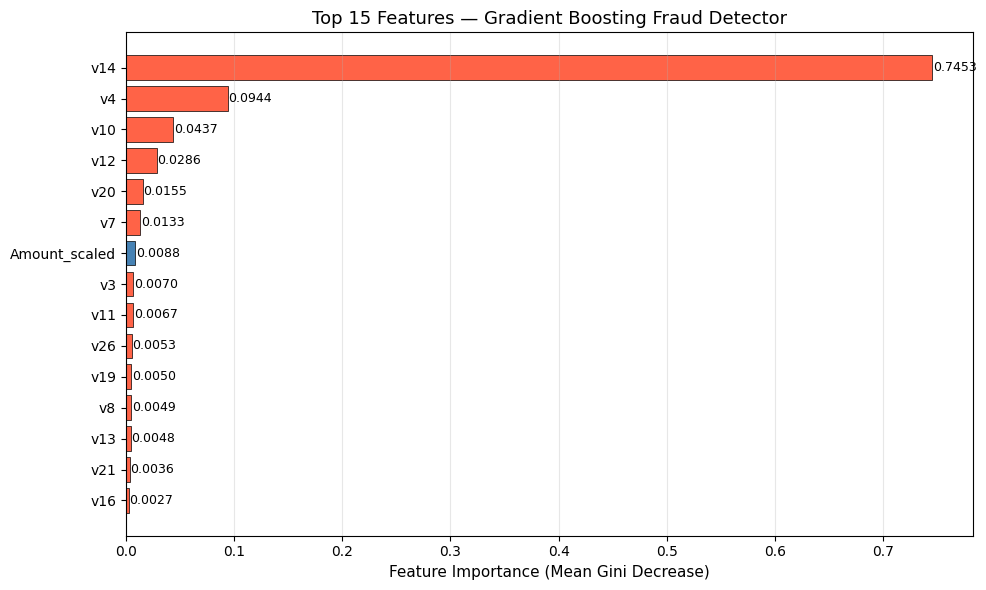

Saved: feature_importance.png

Top 10 features:
      feature  importance
          v14    0.745335
           v4    0.094373
          v10    0.043718
          v12    0.028635
          v20    0.015471
           v7    0.013271
Amount_scaled    0.008782
           v3    0.006952
          v11    0.006707
          v26    0.005317


In [14]:
feature_names = X.columns.tolist()
importances   = best_model.feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 15 features
top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if f.startswith('v') else 'steelblue' for f in top_features['feature']]
bars = ax.barh(top_features['feature'][::-1],
               top_features['importance'][::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, top_features['importance'][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Mean Gini Decrease)', fontsize=11)
ax.set_title(f'Top {top_n} Features — Gradient Boosting Fraud Detector', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: feature_importance.png')
print('\nTop 10 features:')
print(importance_df.head(10).to_string(index=False))

### Feature Importance Insight

**V14 dominates the model**, contributing the majority of predictive power. This suggests that it captures a highly discriminative signal between fraud and legitimate transactions. However it is also worth noting that this also introduces risk, as heavy reliance on a single feature may reduce robustness if underlying patterns shift, in turn making model monitoring and stability checks critical.

---
## 8. Distribution of Top Features by Class

A good sanity check: do the most important features actually separate fraud from legitimate transactions visually? We'd expect fraud and legitimate distributions to overlap minimally for high-importance features.

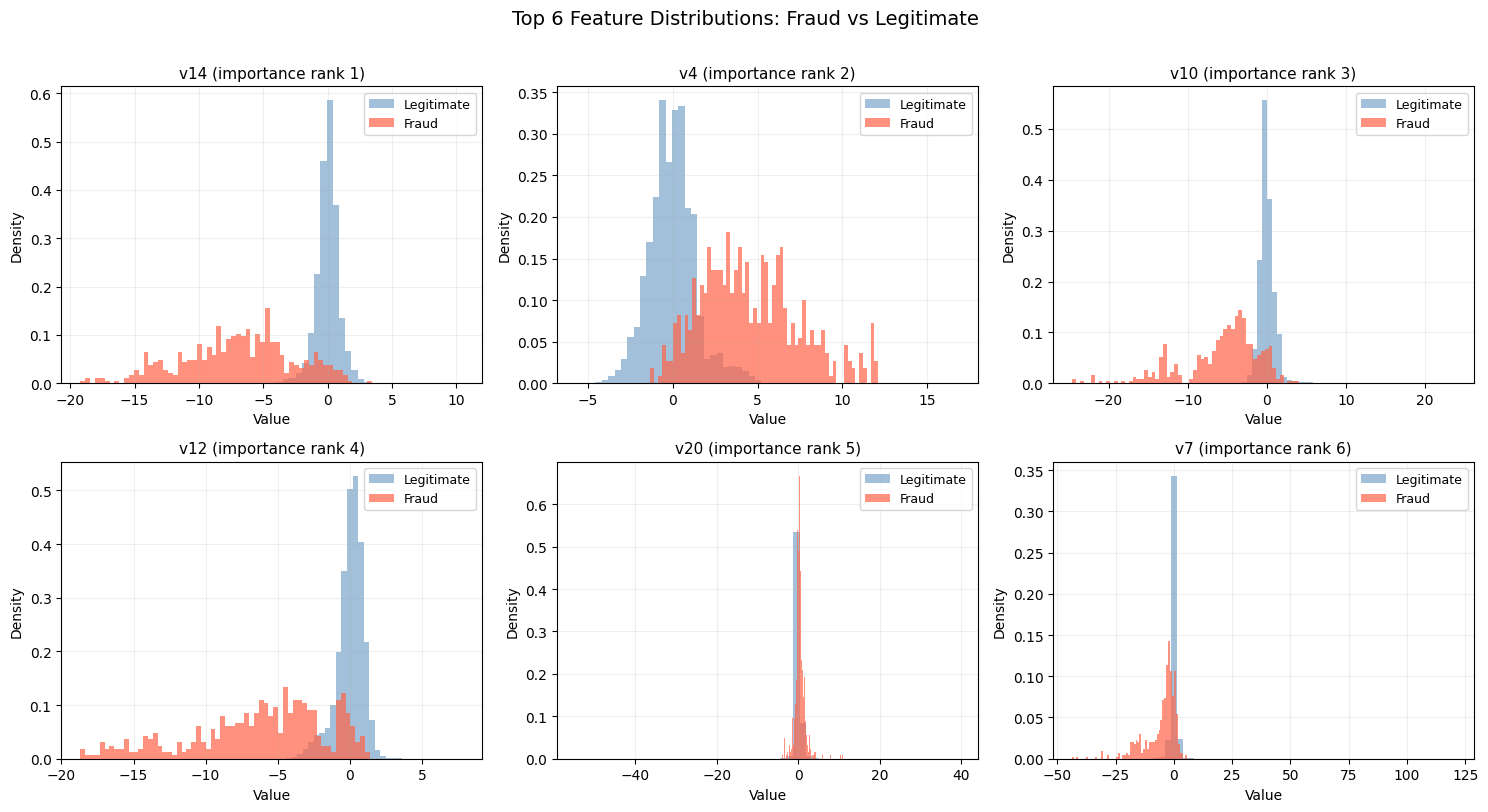

Saved: feature_distributions.png


In [15]:
# Plot distribution of top 6 V-features by class
top_6 = importance_df['feature'].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_6):
    legit_vals = df[df['class'] == False][feat]
    fraud_vals = df[df['class'] == True][feat]

    axes[i].hist(legit_vals, bins=60, alpha=0.5, color='steelblue',
                 label='Legitimate', density=True)
    axes[i].hist(fraud_vals, bins=60, alpha=0.7, color='tomato',
                 label='Fraud', density=True)
    axes[i].set_title(f'{feat} (importance rank {i+1})', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.2)

plt.suptitle('Top 6 Feature Distributions: Fraud vs Legitimate', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

---
## 9. Summary & Next Steps

### What was built
| Step | Technique | Why |
|---|---|---|
| Preprocessing | StandardScaler on Amount/Time | Prevent scale dominance |
| Imbalance | `compute_sample_weight('balanced')` | ~578x fraud penalty; no resampling overhead |
| Model | `GradientBoostingClassifier` (fixed config) | Pure sklearn, no native dependencies; strong tabular baseline |
| Training | Single `fit()` with `sample_weight` | Fixed config baseline to establish performance floor before hyperparameter optimization |
| Evaluation | AUPRC, F1, Precision-Recall curve, Confusion Matrix | Imbalance-aware, threshold-independent metrics |

### Production improvements to consider
1. **Hyperparameter tuning**: add `GridSearchCV` or Optuna over `n_estimators`, `max_depth`, `min_samples_leaf`, and `subsample` once you've confirmed the baseline is working
2. **XGBoost / LightGBM**: 10–100x faster training than sklearn's GradientBoostingClassifier, with native class imbalance handling via scale_pos_weight — the preferred choice for production fraud systems at scale.
3. **Calibration**: use `CalibratedClassifierCV` to ensure `predict_proba` scores reflect true probabilities — important for cost-based threshold setting
4. **Feature engineering**: transaction velocity (# charges in last 60 min), merchant category patterns, time-since-last-transaction
5. **Concept drift monitoring**: fraud patterns evolve; retrain on a rolling window, monitor AUPRC over time, alert when performance degrades
6. **Cost-sensitive threshold**: formalize the threshold decision as `threshold = cost_FP / (cost_FP + cost_FN)` using actual dollar loss estimates

## Key Takeaways

- Fraud detection is fundamentally a **cost-sensitive problem**, not just a modeling problem  
- Threshold selection is as important as model choice  
- A small number of features can dominate performance, but may introduce robustness risk  
- Real-world deployment requires continuous monitoring and adjustment